In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

mpg = sns.load_dataset('mpg')
mpg['origin'] = mpg['origin'].map({'usa':'USA','japan':'Japan','europe':'Europe'})
mpg['model_year'] = mpg['model_year'] + 1900

In [2]:
mpg.head(2)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,1970,USA,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,1970,USA,buick skylark 320


# 4.1 Graphing Basics

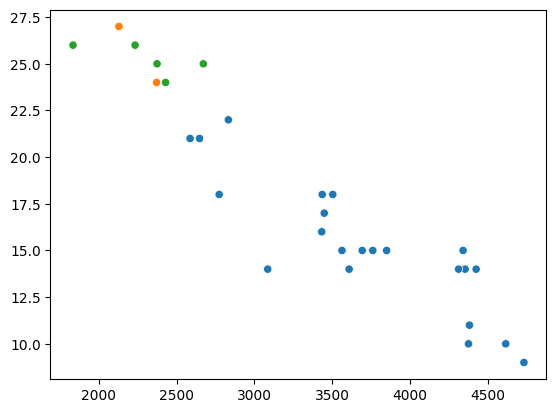

In [3]:
# Graph without labels
mpg_70 = mpg[mpg['model_year'] == 1970]
sns.scatterplot(data=mpg_70, x='weight', y='mpg', hue='origin', legend=False)
plt.xlabel('')
plt.ylabel('')
plt.savefig('../images/Fig4_1_NoLabels.png')

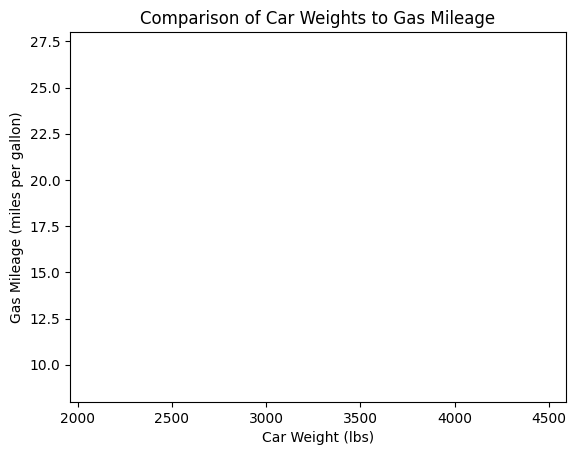

In [4]:
# Labels
plt.figure()
plt.xlim([1960, 4590])
plt.ylim([8.0, 28.0])
plt.title('Comparison of Car Weights to Gas Mileage')
plt.xlabel('Car Weight (lbs)')
plt.ylabel('Gas Mileage (miles per gallon)')
plt.savefig('../images/Fig4_2_OnlyLabels.png')

Text(0, 0.5, 'Gas Mileage (miles per gallon)')

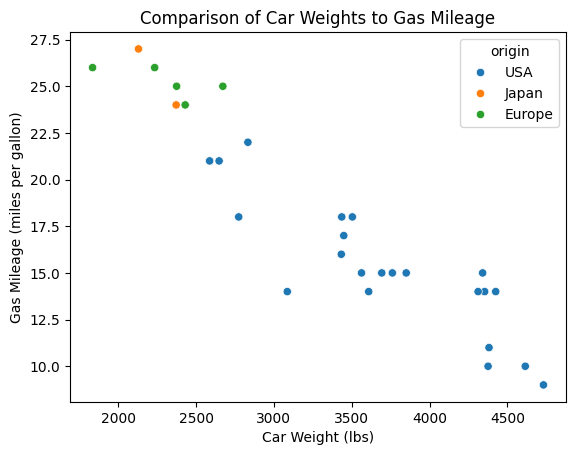

In [5]:
# Graph with the correct labels
mpg_70 = mpg[mpg['model_year'] == 1970]
sns.scatterplot(data=mpg_70, x='weight', y='mpg', hue='origin')
plt.title('Comparison of Car Weights to Gas Mileage')
plt.xlabel('Car Weight (lbs)')
plt.ylabel('Gas Mileage (miles per gallon)')
# plt.savefig('../images/Fig4_3_Labels.png')

# 4.2 Bargraphs

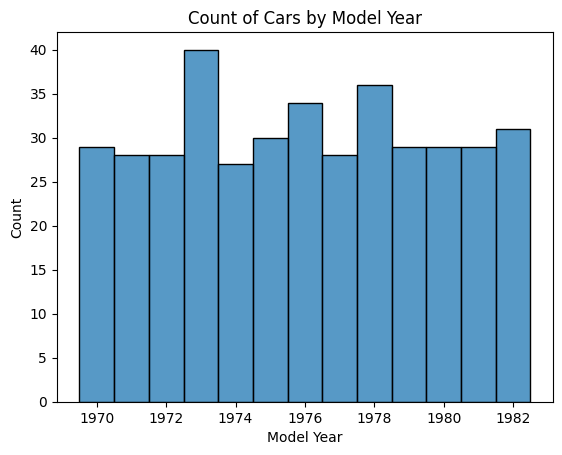

In [6]:
sns.histplot(data=mpg, x='model_year', discrete=True)
plt.xlabel('Model Year')
plt.ylabel('Count')
plt.title('Count of Cars by Model Year')
plt.savefig('../images/Fig4_2_Bargraph.png')

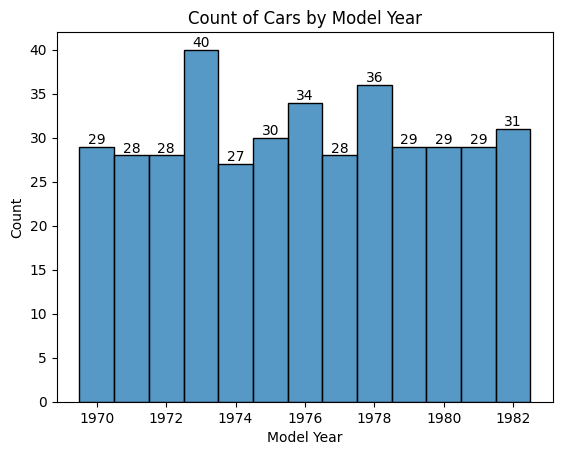

In [7]:
ax = sns.histplot(data=mpg, x='model_year', discrete=True)
plt.xlabel('Model Year')
plt.ylabel('Count')
plt.title('Count of Cars by Model Year')
ax.bar_label(ax.containers[0])
plt.savefig('../images/Fig4_2_BargraphWithCounts.png')

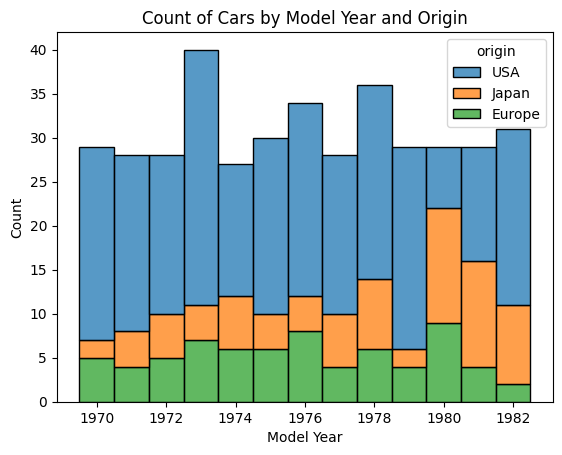

In [8]:
sns.histplot(data=mpg, x='model_year', hue='origin', multiple='stack', discrete=True)
plt.xlabel('Model Year')
plt.ylabel('Count')
plt.title('Count of Cars by Model Year and Origin')
plt.savefig('../images/Fig4_2_StackedBargraph.png')

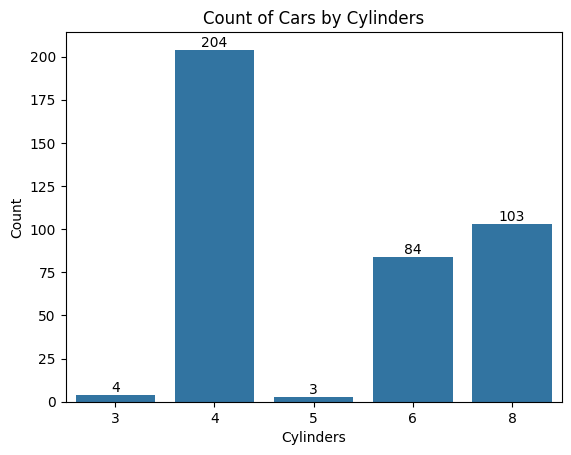

In [9]:
# sns.countplot(data=mpg, x='origin', order=['Japan','Europe','USA'])
ax = sns.countplot(data=mpg, x='cylinders')
plt.xlabel('Cylinders')
plt.ylabel('Count')
plt.title('Count of Cars by Cylinders')
ax.bar_label(ax.containers[0])
plt.savefig('../images/Fig4_2_Countplot.png')

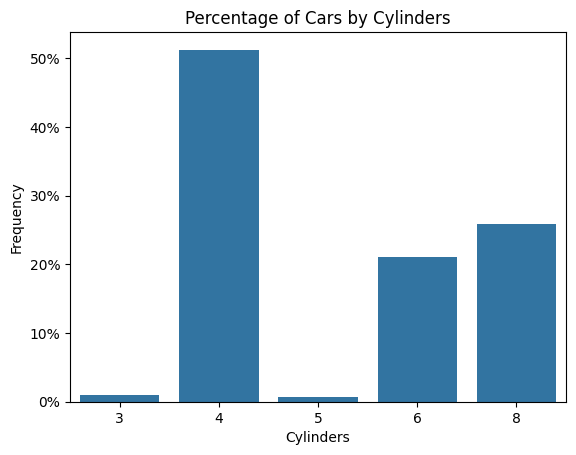

In [10]:
fig, ax = plt.subplots()
sns.countplot(data=mpg, x='cylinders', stat='percent')
plt.xlabel('Cylinders')
plt.ylabel('Frequency')
plt.title('Percentage of Cars by Cylinders')
ax.yaxis.set_major_formatter('{x:.0f}%')

plt.savefig('../images/Fig4_2_PercentCountplot.png')

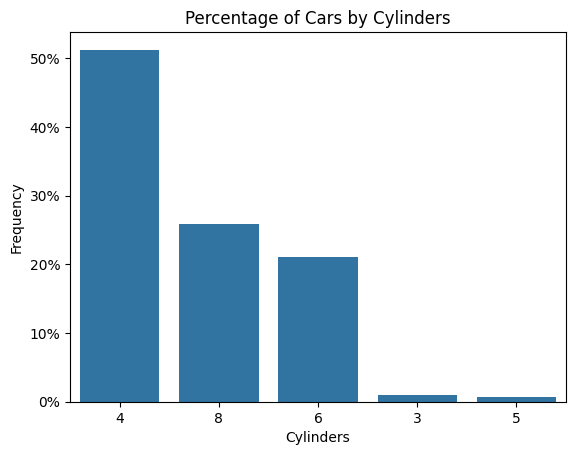

In [11]:
fig, ax = plt.subplots()
sns.countplot(data=mpg, x='cylinders', stat='percent', order=[4,8,6,3,5], ax=ax)
plt.xlabel('Cylinders')
plt.ylabel('Frequency')
plt.title('Percentage of Cars by Cylinders')
ax.yaxis.set_major_formatter('{x:.0f}%')
plt.savefig('../images/Fig4_2_ParetoChart.png')

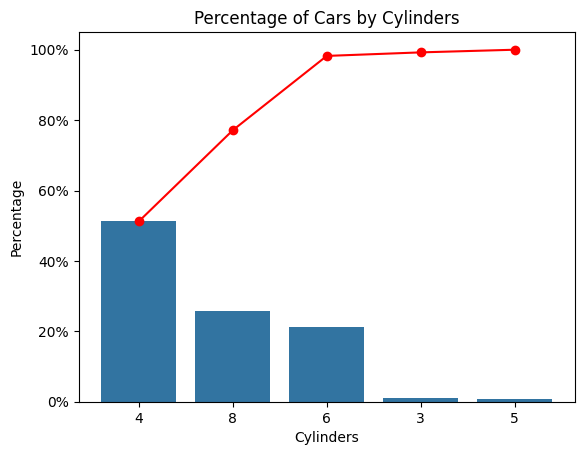

In [12]:
freq = mpg['cylinders'].value_counts(normalize=True).reset_index()
freq.columns = ['cylinders', 'percentage']
freq = freq.sort_values(by='percentage', ascending=False)
freq['percentage'] *= 100
freq['cumulative'] = freq['percentage'].cumsum()

fig, ax = plt.subplots()
sns.countplot(data=mpg, x='cylinders', stat='percent', order=[4,8,6,3,5], ax=ax)
plt.xlabel('Cylinders')
plt.ylabel('Percentage')
plt.title('Percentage of Cars by Cylinders')
ax.yaxis.set_major_formatter('{x:.0f}%')

ax.plot(freq.index, freq['cumulative'], color='red', marker='o', linestyle='-', label='Cumulative Percentage')
plt.savefig('../images/Fig4_2_ParetoChartCumulative.png')

In [13]:
freq

,cylinders,percentage,cumulative
0,4,51.256281,51.256281
1,8,25.879397,77.135678
2,6,21.105528,98.241206
3,3,1.005025,99.246231
4,5,0.753769,100.000000


# 4.3 Pie Charts

In [14]:
mpg['origin'].value_counts()

origin
USA       249
Japan      79
Europe     70
Name: count, dtype: int64

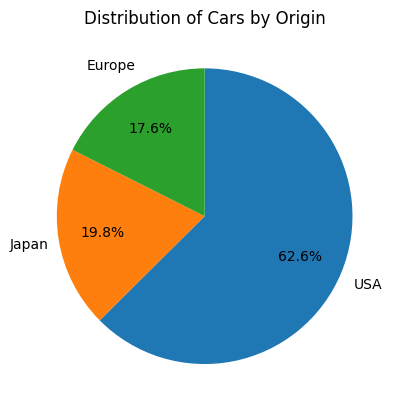

In [15]:
_, texts, _ = plt.pie(mpg['origin'].value_counts(),
        labels=['USA','Japan','Europe'], #mpg['origin'].value_counts().index,
        autopct='%1.1f%%',
        pctdistance=0.7,
        labeldistance=1.2,
        startangle=90,
        counterclock=False)

for t in texts:
    t.set_horizontalalignment('center')
    t.set_verticalalignment('center')

plt.title('Distribution of Cars by Origin')
plt.savefig('../images/Fig4_3_Piechart.png')

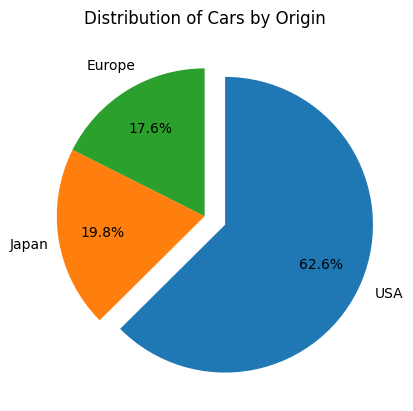

In [16]:
explode_dist = (0.15, 0, 0)

_, texts, _ = plt.pie(mpg['origin'].value_counts(),
        labels=['USA','Japan','Europe'], #mpg['origin'].value_counts().index,
        autopct='%1.1f%%',
        pctdistance=0.7,
        labeldistance=1.2,
        startangle=90,
        counterclock=False,
        explode=explode_dist)

for t in texts:
    t.set_horizontalalignment('center')
    t.set_verticalalignment('center')

plt.title('Distribution of Cars by Origin')

plt.savefig('../images/Fig4_3_PiechartUSA.png')

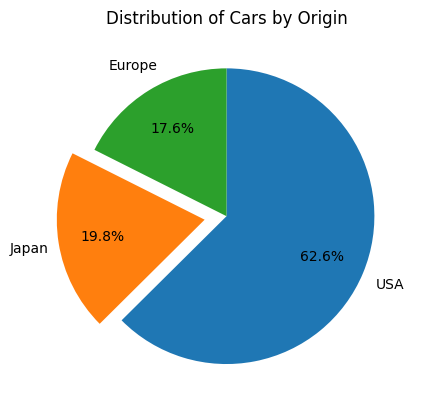

In [17]:
explode_dist = (0, 0.15, 0)

_, texts, _ = plt.pie(mpg['origin'].value_counts(),
        labels=['USA','Japan','Europe'], #mpg['origin'].value_counts().index,
        autopct='%1.1f%%',
        pctdistance=0.7,
        labeldistance=1.2,
        startangle=90,
        counterclock=False,
        explode=explode_dist)

for t in texts:
    t.set_horizontalalignment('center')
    t.set_verticalalignment('center')

plt.title('Distribution of Cars by Origin')
plt.savefig('../images/Fig4_3_PiechartJapan.png')

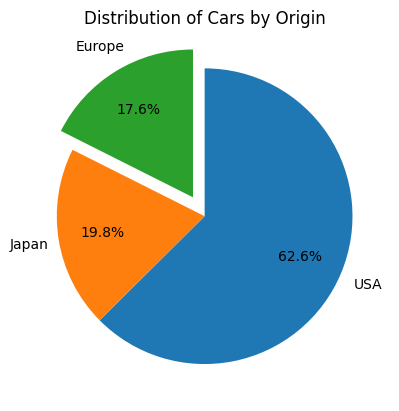

In [18]:
explode_dist = (0, 0, 0.15)

_, texts, _ = plt.pie(mpg['origin'].value_counts(),
        labels=['USA','Japan','Europe'], #mpg['origin'].value_counts().index,
        autopct='%1.1f%%',
        pctdistance=0.7,
        labeldistance=1.2,
        startangle=90,
        counterclock=False,
        explode=explode_dist)

for t in texts:
    t.set_horizontalalignment('center')
    t.set_verticalalignment('center')

plt.title('Distribution of Cars by Origin')

plt.savefig('../images/Fig4_3_PiechartEurope.png')

# 4.4 Dotplots

In [19]:
x = []
y = []

for yr in np.arange(1970, 1983, 1):
    for i in range(mpg[(mpg['origin'] == 'Europe') & (mpg['model_year'] == yr)].shape[0]):
        x.append(yr)
        y.append(i+1)

print(x)
print(y)

[np.int64(1970), np.int64(1970), np.int64(1970), np.int64(1970), np.int64(1970), np.int64(1971), np.int64(1971), np.int64(1971), np.int64(1971), np.int64(1972), np.int64(1972), np.int64(1972), np.int64(1972), np.int64(1972), np.int64(1973), np.int64(1973), np.int64(1973), np.int64(1973), np.int64(1973), np.int64(1973), np.int64(1973), np.int64(1974), np.int64(1974), np.int64(1974), np.int64(1974), np.int64(1974), np.int64(1974), np.int64(1975), np.int64(1975), np.int64(1975), np.int64(1975), np.int64(1975), np.int64(1975), np.int64(1976), np.int64(1976), np.int64(1976), np.int64(1976), np.int64(1976), np.int64(1976), np.int64(1976), np.int64(1976), np.int64(1977), np.int64(1977), np.int64(1977), np.int64(1977), np.int64(1978), np.int64(1978), np.int64(1978), np.int64(1978), np.int64(1978), np.int64(1978), np.int64(1979), np.int64(1979), np.int64(1979), np.int64(1979), np.int64(1980), np.int64(1980), np.int64(1980), np.int64(1980), np.int64(1980), np.int64(1980), np.int64(1980), np.int6

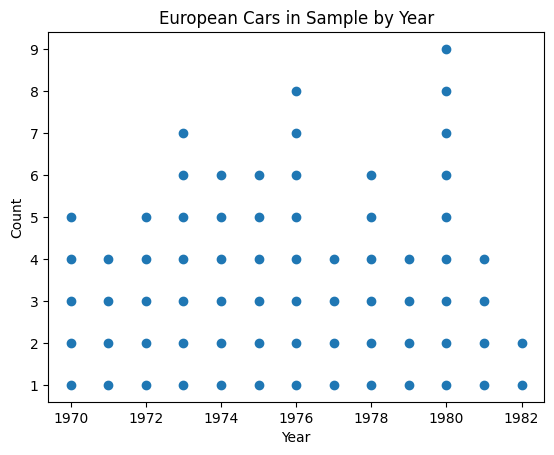

In [20]:
# Basic Dotplot
years = np.arange(1970,1983,1)
counts = np.zeros_like(years)
x = []
y = []

for car in mpg[mpg['origin'] == 'Europe'].itertuples():
    yr = car.model_year
    i = yr - 1970
    counts[i] += 1
    x.append(yr)
    y.append(counts[i])

plt.scatter(x,y)
plt.title('European Cars in Sample by Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.savefig('../images/Fig4_4_Dotplot.png')

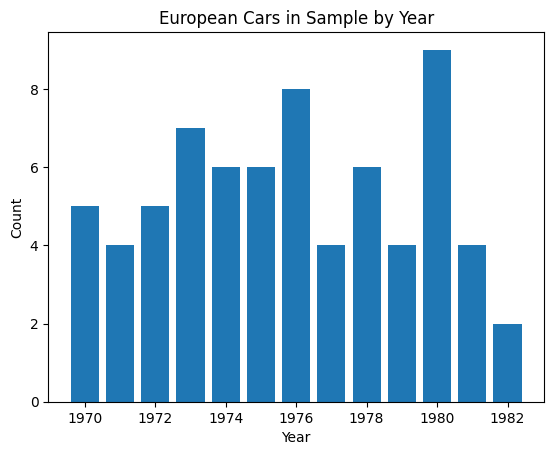

In [21]:
plt.bar(years, counts)
plt.title('European Cars in Sample by Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.savefig('../images/Fig4_4_DotplotAsBars.png')

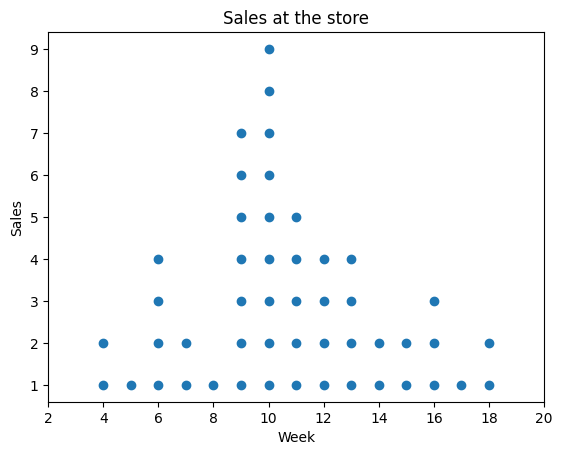

In [22]:
# Practice question 1
a = [4, 4, 5, 6, 6, 6, 6, 7, 7, 8, 9, 9, 9, 9, 9, 9, 9, 10, 10, 10, 10, 10, 10, 10, 10, 10, 11, 11, 11, 11, 11, 12, 12, 12, 12, 13, 13, 13, 13,14, 14, 15, 15, 16, 16, 16, 17, 18, 18]
counts = np.zeros_like(a)

x = []
y = []

for p in a:
    i = p - 4
    counts[i] += 1
    x.append(p)
    y.append(counts[i])

plt.scatter(x,y)
plt.xlim([2,20])#[min(precip)-2, max(precip)+2])
plt.title('Sales at the store')
plt.xlabel('Week')
plt.ylabel('Sales')
plt.savefig('../images/Fig4_4_DotplotPractice1.png')

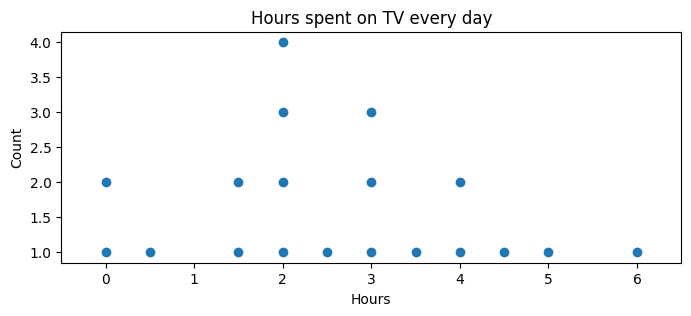

In [23]:
# Practice question 2
plt.figure(figsize=(8,3))
tv = [0, 0, 0.5, 1.5, 1.5, 2, 2, 2, 2, 2.5, 3, 3, 3, 3.5, 4, 4, 4.5, 5, 6]
counts = np.zeros_like(tv)

x = []
y = []

for p in tv:
    i = int(p * 2)  # Convert to integer index
    counts[i] += 1
    x.append(p)
    y.append(counts[i])

plt.scatter(x,y)
plt.xlim([-0.5,6.5])
plt.title('Hours spent on TV every day')
plt.xlabel('Hours')
plt.ylabel('Count')
plt.savefig('../images/Fig4_4_DotplotPractice2.png')

## 4.5 Stem-and-leaf plots

In [24]:
mpg['mpg'].describe()

count    398.000000
mean      23.514573
std        7.815984
min        9.000000
25%       17.500000
50%       23.000000
75%       29.000000
max       46.600000
Name: mpg, dtype: float64

In [25]:
stems = {}

for n in mpg['mpg']:
    s, l = divmod(n, 10)
    stems.setdefault(s, []).append(int(l))

for s in sorted(stems):
    print(f"{int(s)} | {''.join(map(str, sorted(stems[s])))}")

print()
print("Key: 1 | 2 means 12 mpg")

0 | 9
1 | 001111222222333333333333333333334444444444444444444455555555555555555555566666666666666666677777777777777788888888888888888888888899999999999999999999
2 | 00000000000000000000111111111111122222222222223333333333333333344444444444444455555555555555555666666666666666666677777777777777788888888888889999999999999
3 | 00000000000111111111111122222222222222333333334444444444555566666666677777788888999
4 | 001334446

Key: 1 | 2 means 12 mpg


## 4.6 Scatterplots

In [48]:
mpg.head(1)['weight'][0]

np.int64(3504)

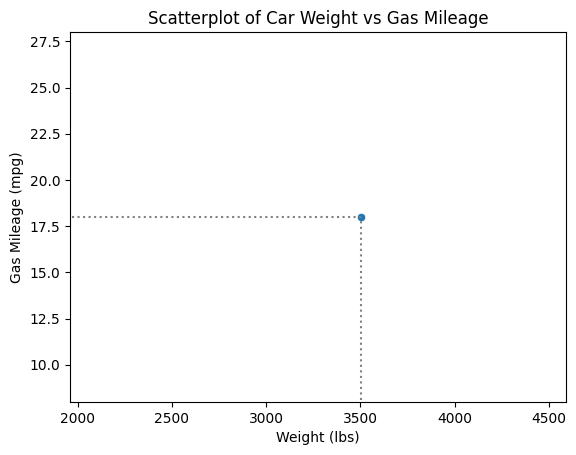

In [55]:
x = mpg.head(1)['weight'][0]
y = mpg.head(1)['mpg'][0]

sns.scatterplot(data=mpg.head(1), x='weight', y='mpg')
plt.plot([x,x],[8.1,y], linestyle=':', color='grey')
plt.plot([1970,x],[y,y], linestyle=':', color='grey')
plt.xlim([1960, 4590])
plt.ylim([8.0, 28.0])
plt.xlabel('Weight (lbs)')
plt.ylabel('Gas Mileage (mpg)')
plt.title('Scatterplot of Car Weight vs Gas Mileage')
plt.savefig('../images/Fig4_6_Scatterplot-1point.png')

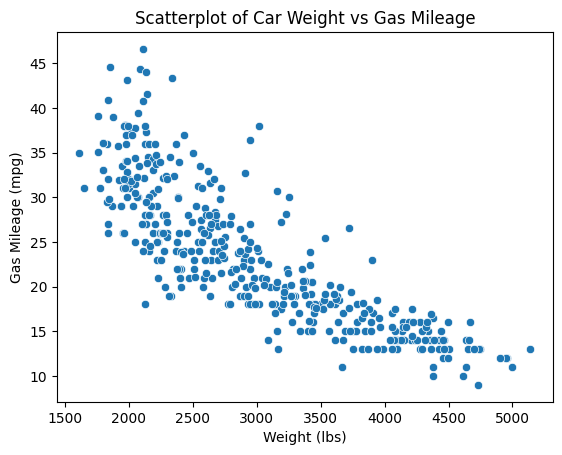

In [26]:
sns.scatterplot(data=mpg, x='weight', y='mpg')
plt.xlabel('Weight (lbs)')
plt.ylabel('Gas Mileage (mpg)')
plt.title('Scatterplot of Car Weight vs Gas Mileage')
plt.savefig('../images/Fig4_6_Scatterplot.png')

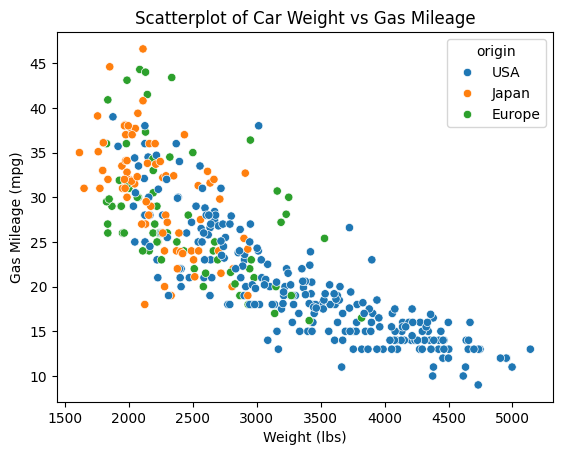

In [27]:
sns.scatterplot(data=mpg, x='weight', y='mpg', hue='origin')
plt.xlabel('Weight (lbs)')
plt.ylabel('Gas Mileage (mpg)')
plt.title('Scatterplot of Car Weight vs Gas Mileage')
plt.savefig('../images/Fig4_6_ColoredScatterplot.png')

## 4.7 Timeseries

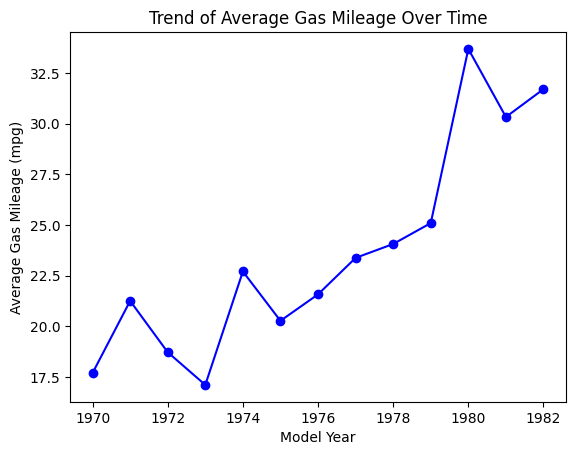

In [28]:
yearly_mpg = mpg.groupby('model_year')['mpg'].mean().reset_index()
yearly_mpg_std = mpg.groupby('model_year')['mpg'].std().reset_index()

plt.plot(yearly_mpg['model_year'], yearly_mpg['mpg'], marker='o', color='blue')
plt.xlabel('Model Year')
plt.ylabel('Average Gas Mileage (mpg)')
plt.title('Trend of Average Gas Mileage Over Time')
plt.savefig('../images/Fig4_7_Timeseries.png')

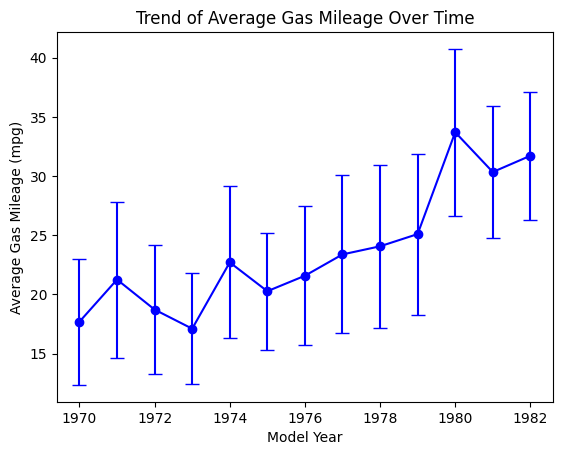

In [29]:
plt.errorbar(yearly_mpg['model_year'], yearly_mpg['mpg'], yerr=yearly_mpg_std['mpg'], fmt='o-', color='blue', capsize=5) 
plt.xlabel('Model Year')
plt.ylabel('Average Gas Mileage (mpg)')
plt.title('Trend of Average Gas Mileage Over Time')
plt.savefig('../images/Fig4_7_TimeseriesErrorbars.png')

## Figures for Practice Questions

,country_code,country,country_long,Gold Medal,Silver Medal,Bronze Medal,Total
0,USA,United States,United States of America,40,44,42,126
1,CHN,China,People's Republic of China,40,27,24,91
2,JPN,Japan,Japan,20,12,13,45
3,AUS,Australia,Australia,18,19,16,53
4,FRA,France,France,16,26,22,64
5,NED,Netherlands,Netherlands,15,7,12,34
6,GBR,Great Britain,Great Britain,14,22,29,65
7,KOR,Korea,Republic of Korea,13,9,10,32
8,ITA,Italy,Italy,12,13,15,40
9,GER,Germany,Germany,12,13,8,33


/var/folders/qk/b_fqr8c925l80p4m9dkk0wth0000gn/T/ipykernel_25630/3417448844.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(medals10['country'], rotation=90)


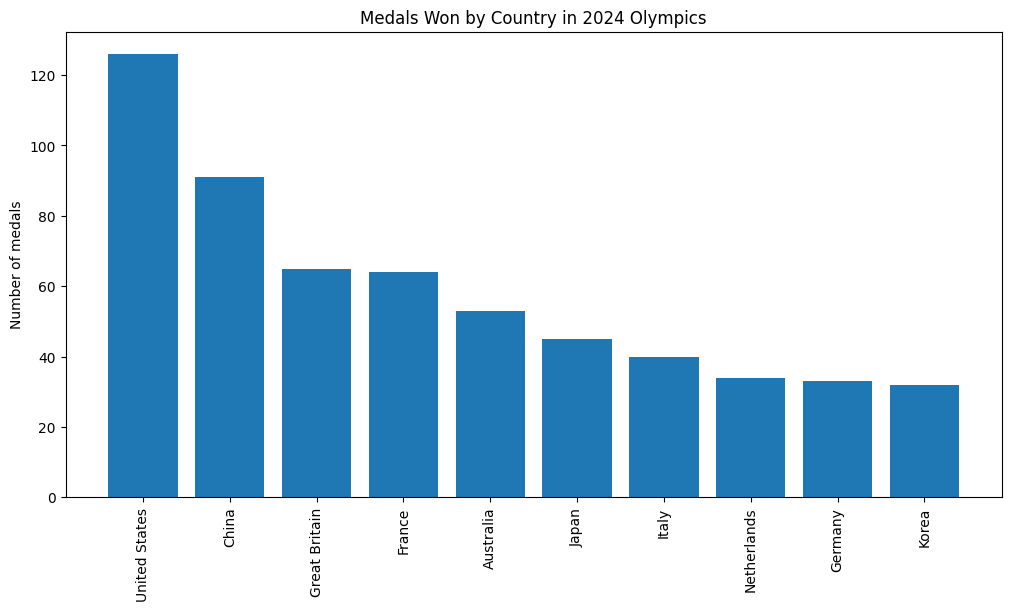

In [ ]:
# Problem 4.2.2
medals = pd.read_csv('2024olympics_medals_total.csv')
medals = medals.sort_values('Gold Medal', ascending=False)
medals10 = medals.head(10)
display(medals10)
medals10 = medals10.sort_values('Total', ascending=False)

# Quantitative comparisons: bar-charts
fig, ax = plt.subplots(figsize=(10,6), layout='constrained')
ax.bar(medals10['country'], medals10['Total'])
# ax.bar(medals10['country'], medals10['Gold Medal'], label='Gold', color='yellow')
# ax.bar(medals10['country'], medals10['Silver Medal'], bottom=medals10['Gold Medal'], label='Silver', color='gray')
# ax.bar(medals10['country'], medals10['Bronze Medal'], bottom=medals10['Gold Medal']+medals10['Silver Medal'], label='Bronze', color='tan')
ax.set_xticklabels(medals10['country'], rotation=90)
ax.set_ylabel('Number of medals')
ax.set_title('Medals Won by Country in 2024 Olympics')
# ax.legend()
# plt.show()
plt.savefig('../images/Fig422_Solution.png')

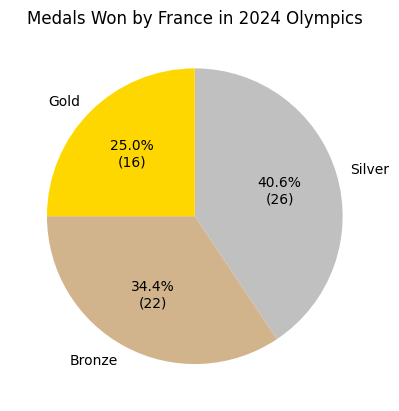

In [ ]:
# Problem 4.3.1
france = medals[medals['country'] == 'France'][['Silver Medal', 'Bronze Medal', 'Gold Medal']]

def format_values(pct):
    absolute = int(round(pct * 64 / 100.0))
    return f"{pct:.1f}%\n({absolute:d})"

plt.pie(france.values[0], labels=['Silver', 'Bronze', 'Gold'], 
        autopct=format_values, 
        startangle=90, 
        colors=['silver', 'tan', 'gold'],
        counterclock=False)

plt.title('Medals Won by France in 2024 Olympics')
plt.savefig('../images/Fig431_Solution.png')

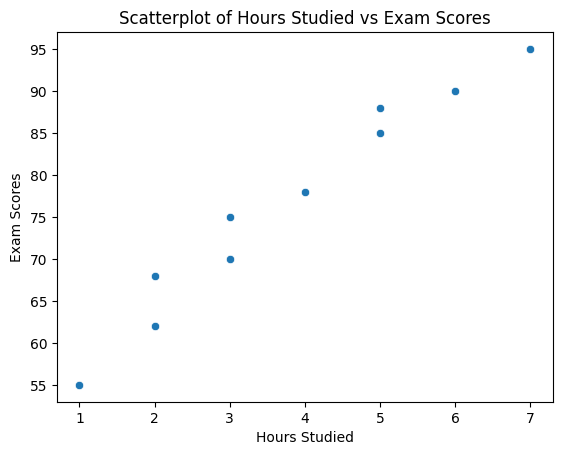

In [ ]:
# Problem 4.6.1
hrs_studies = np.array([1,2,2,3,3,4,5,5,6,7])
exam_scores = np.array([55,62,68,70,75,78,85,88,90,95])

sns.scatterplot(x=hrs_studies, y=exam_scores)
plt.xlabel("Hours Studied")
plt.ylabel("Exam Scores")
plt.title("Scatterplot of Hours Studied vs Exam Scores")

plt.savefig('../images/Fig461_Solution.png')

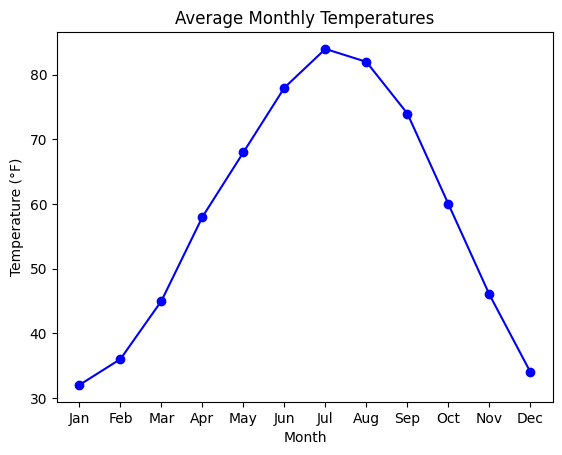

In [ ]:
# Problem 4.7.1
month = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
temp = [32, 36, 45, 58, 68, 78, 84, 82, 74, 60, 46, 34]

plt.plot(month, temp, marker='o', linestyle='-', color='blue')
plt.title('Average Monthly Temperatures')
plt.xlabel('Month')
plt.ylabel('Temperature (°F)')
plt.savefig('../images/Fig471_Solution.png')

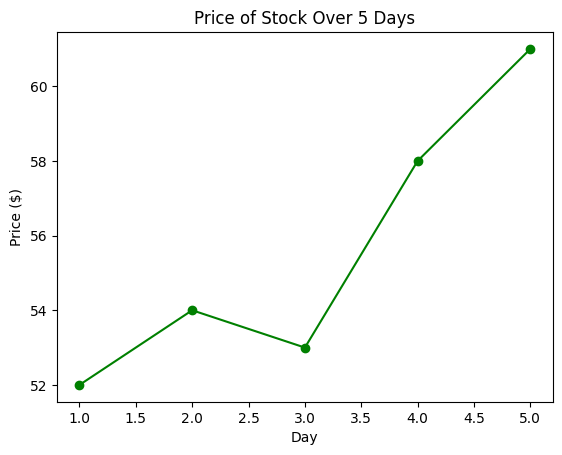

In [7]:
# Problem 4.7.2
day = [1,2,3,4,5]
price = [52, 54, 53, 58, 61]

plt.plot(day, price, marker='o', linestyle='-', color='green')
plt.title('Price of Stock Over 5 Days')
plt.xlabel('Day')
plt.ylabel('Price ($)')
plt.savefig('../images/Fig472_Solution.png')